In [1]:
from pathlib import Path
import sys
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.abcode.tools.utils.plot_utils import heatmap, get_corrmat_corrlist, get_high_correlation_pairs, get_dict_of_features_with_highcorr
from project_config.variables import address_dict

# Section 1: Resolve repo root from either project root or notebooks/ cwd.
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd
os.chdir(repo_root)

# Section 2: Add repo and src roots to sys.path for imports.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print("repo_root:", repo_root)
print("src_root:", src_root)


repo_root: /Users/charmainechia/Documents/projects/AbCode
src_root: /Users/charmainechia/Documents/projects/AbCode/src


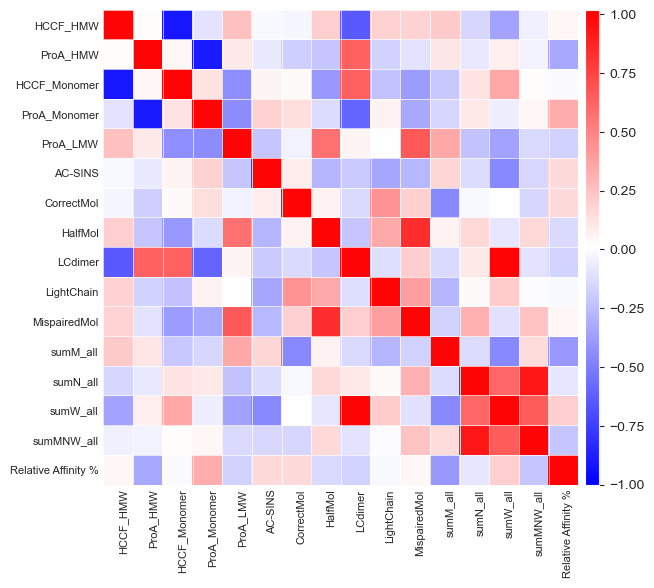

In [7]:
# load dataframe
data_fbase = address_dict['biostream-developability-data']
data_subfolder = 'tubespin'
csv_suffix = '_long' # '' #
csv_fname = f'{data_subfolder}{csv_suffix}.csv'
csv_fpath = f'{data_fbase}expdata/{data_subfolder}/{csv_fname}'
use_abs_vals = False
method = 'spearman'
cmap = 'bwr' # 'plasma' #
savefig = f'{data_fbase}expdata/{data_subfolder}/correlations{csv_suffix}'
col_metadata = ['Batch', 'Samples', 'Media']
media_suffix_list = ['_Excell'] # ['_Excell','_ActiPro']
cols_sequence = [
    'CD20-VH-CH1_HCK', 'G4S Linker1_HCK', 'CD3 VH_HCK', 'G4S Linker2_HCK', 'CD3 VL_HCK', 'HCK','Overall_HeavyChainKnob', 'CD20-VH-CH1_HCH', 'HCH', 'Overall_HCH', 'CD20-VL-CL_LC1', 'CD20-VL-CL_LC1.1']
cols_measurements = [
    'HCCF_HMW', 'ProA_HMW', 'HCCF_Monomer', 'ProA_Monomer', 'HCCF_LMW', 'ProA_LMW',
    'AC-SINS',
    'CorrectMol', 'HalfMol', 'LCdimer', 'LightChain', 'MispairedMol',
    'sumM_all', 'sumN_all', 'sumW_all', 'sumMNW_all',
    # 'sumM_common', 'sumN_common', 'sumW_common', 'sumMNW_common',
    'Relative Affinity %',
]
cols_measurements_wmediasuffix = [f'{c}{media_suffix}' for c in cols_measurements for media_suffix in media_suffix_list if c not in ['Relative Affinity %']] + ['Relative Affinity %']

# load data
if csv_suffix == '':
    cols = cols_measurements_wmediasuffix
elif csv_suffix == '_long':
    cols = cols_measurements
df = pd.read_csv(csv_fpath)
XYarr = df[cols]

corr_mat, corr_all = get_corrmat_corrlist(XYarr, method=method, sort_corrlist=True, csv_fname=csv_fname,
                                          savefig=savefig, plot_corrmat=True, plot_clustermap=False, use_abs_vals=use_abs_vals, cmap=cmap, set_diagonal_to_nan=False)

In [8]:
# overall correlation stats
print('Mean abs X corr:', round(corr_all['corr_abs'].mean(),2))
print('Stdev abs X corr:', round(corr_all['corr_abs'].std(),2))
print('Median abs X corr:', round(corr_all['corr_abs'].median(),2))


corr_thres = round(corr_all['corr_abs'].mean() + corr_all['corr_abs'].std(),3)
print(f'Frac of feature pairs with corr > {corr_thres}:', round(len(corr_all[corr_all['corr_abs']>corr_thres])/len(corr_all),2))

# get high correlation pairs
# get pairs with high correlations
corr_selected = get_high_correlation_pairs(
    corr_all, corr_thres=corr_thres, print_out=True)
print()

# for each variable, print list of other variables with which it has high correlation
highcorr_vars_dict = get_dict_of_features_with_highcorr(
    corr_mat, corr_thres=corr_thres)


Mean abs X corr: 0.23
Stdev abs X corr: 0.22
Median abs X corr: 0.16
Frac of feature pairs with corr > 0.45: 0.13
0 (LCdimer, sumW_all): 1.0
1 (sumMNW_all, sumN_all): 0.9312
2 (HCCF_HMW, HCCF_Monomer): -0.9085
3 (ProA_HMW, ProA_Monomer): -0.8924
4 (HalfMol, MispairedMol): 0.8344
5 (MispairedMol, ProA_LMW): 0.668
6 (sumMNW_all, sumW_all): 0.6531
7 (HCCF_HMW, LCdimer): -0.6412
8 (LCdimer, ProA_HMW): 0.6353
9 (HCCF_Monomer, LCdimer): 0.6324
10 (sumN_all, sumW_all): 0.6175
11 (LCdimer, ProA_Monomer): -0.6
12 (HalfMol, ProA_LMW): 0.5746
13 (CorrectMol, sumM_all): -0.4625
14 (sumM_all, sumW_all): -0.4583
15 (AC-SINS, sumW_all): -0.4556

0 HCCF_HMW : HCCF_Monomer LCdimer
1 ProA_HMW : ProA_Monomer LCdimer
2 HCCF_Monomer : HCCF_HMW LCdimer
3 ProA_Monomer : ProA_HMW LCdimer
4 ProA_LMW : HalfMol MispairedMol
5 AC-SINS : sumW_all
6 CorrectMol : sumM_all
7 HalfMol : ProA_LMW MispairedMol
8 LCdimer : HCCF_HMW ProA_HMW HCCF_Monomer ProA_Monomer sumW_all
9 LightChain :
10 MispairedMol : ProA_LMW HalfM